In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import pyplot

import sys
sys.path.append('../magnus')

import oscprob
import oscprobstd
import hamiltonians2nu
import matter
import globaldefs as gd

# import magnus.oscprob as oscprob
# import magnus.oscprobstd as oscprobstd
# import magnus.hamiltonians2nu as hamiltonians2nu
# import magnus.matter as matter
# import magnus.globaldefs as gd




Bad key text.latex.preview in file matplotlibrc, line 243 ('text.latex.preview  : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.5.3/matplotlibrc.template
or from the matplotlib source distribution


In [2]:
col_full = '#E76F51'
col_ang = '#2A9D8F'
col_en = '#E9C46A'
col_count = '#73A8BF'#'#2A9D8F'


In [3]:
def prob_label(nu_i, nu_f):
    if (nu_i == gd.NUE):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_e \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_e \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_e \to \nu_\tau}$'
    elif (nu_i == gd.NUMU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\mu \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\mu \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\mu \to \nu_\tau}$'
    elif (nu_i == gd.NUTAU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\tau \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\tau \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\tau \to \nu_\tau}$'
    return label

# 1. Probabilities 2$\nu$: in vacuum

In [4]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF # [adim]
Dm2 = gd.D21_NO_BF # [eV^2]

## 1.1 Probabilities vs. distance

### Generate probabilities

In [11]:
# Baselines
l_ini, l_fin = 1.e1, 1.e5 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 10.0*gd.UNIT_MEV # [eV]
# Using standard formula
prob_std = np.array([oscprobstd.osc_prob_2nu_vacuum_std(sth, Dm2, energy, l*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f] for l in distances])
# Using Magnus expansion
H_func = lambda l: hamiltonians2nu.hamiltonian_2nu_vacuum(energy, sth, Dm2, compute_matrix_multiplication=False)
prob = np.array([oscprob.osc_prob(H_func, 0.0, l*gd.CONV_KM_TO_INV_EV, magnus_exp_order=2)[nu_i][nu_f] for l in distances])

### Plot probabilities

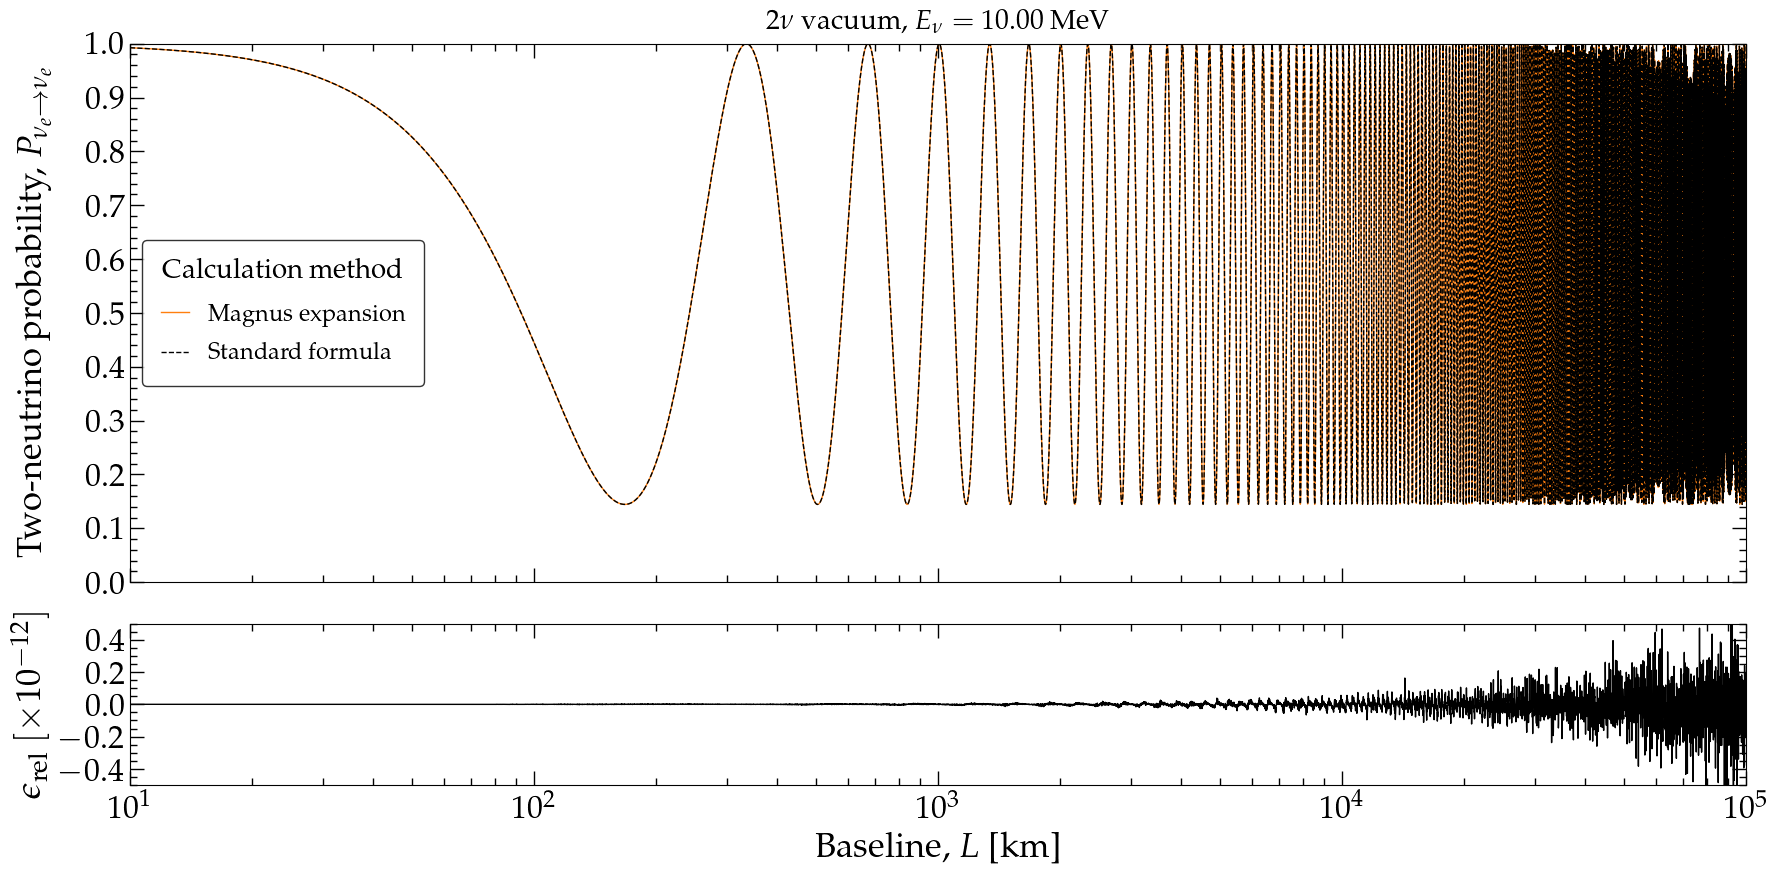

In [12]:
heights = [1.0, 0.3]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    # constrained_layout=True, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

ax[0].plot(distances, prob, lw=1, color='C1', ls='-', label='Magnus expansion')
ax[0].plot(distances, prob_std, lw=1, color='k', ls='--', label='Standard formula')
ax[1].plot(distances, (prob-prob_std)/prob_std/1.e-12, lw=1, color='k', ls='-')

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='center left', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1,
             title=r'Calculation method')

# Formatting
ax[0].set_ylabel(r'Two-neutrino probability,~'+prob_label(nu_i, nu_f), labelpad=25)
ax[0].set_xlim(l_ini, l_fin)
ax[0].set_ylim(0, 1)
ax[0].set_xscale('log')
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax[0].xaxis.set_ticklabels([])
ax[1].set_xlabel(r'Baseline, $L$ [km]')
ax[1].set_ylabel(r'$\epsilon_{\rm rel}~[\times 10^{-12}]$', labelpad=7)
ax[1].set_xscale('log')
ax[1].set_xlim(l_ini, l_fin)
ax[1].set_ylim(-0.5,0.5)
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.20))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.05))
ax[0].set_title(r'$2\nu$~vacuum, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV), fontsize=20, pad=10)

# Save plot
plt.tight_layout()
plt.savefig('../fig/prob_2nu_vacuum_vs_baseline.pdf', dpi=200)

## 1.2 Probabilities vs. energy

### Generate probabilities

In [13]:
# Baselines
energy_min, energy_max = 1.e-1, 1.e1 # [GeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [GeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = 5.e3 # [km]
# Using standard formula
prob_std = np.array([oscprobstd.osc_prob_2nu_vacuum_std(sth, Dm2, enu*gd.UNIT_GEV, baseline*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f] \
                     for enu in energies])
# Using Magnus expansion
H = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2, compute_matrix_multiplication=False) # Vacuum H without (1/E)
prob = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_GEV))*H, 0.0, gd.CONV_KM_TO_INV_EV*baseline, magnus_exp_order=2)[nu_i][nu_f] \
                 for enu in energies])

### Plot probabilities

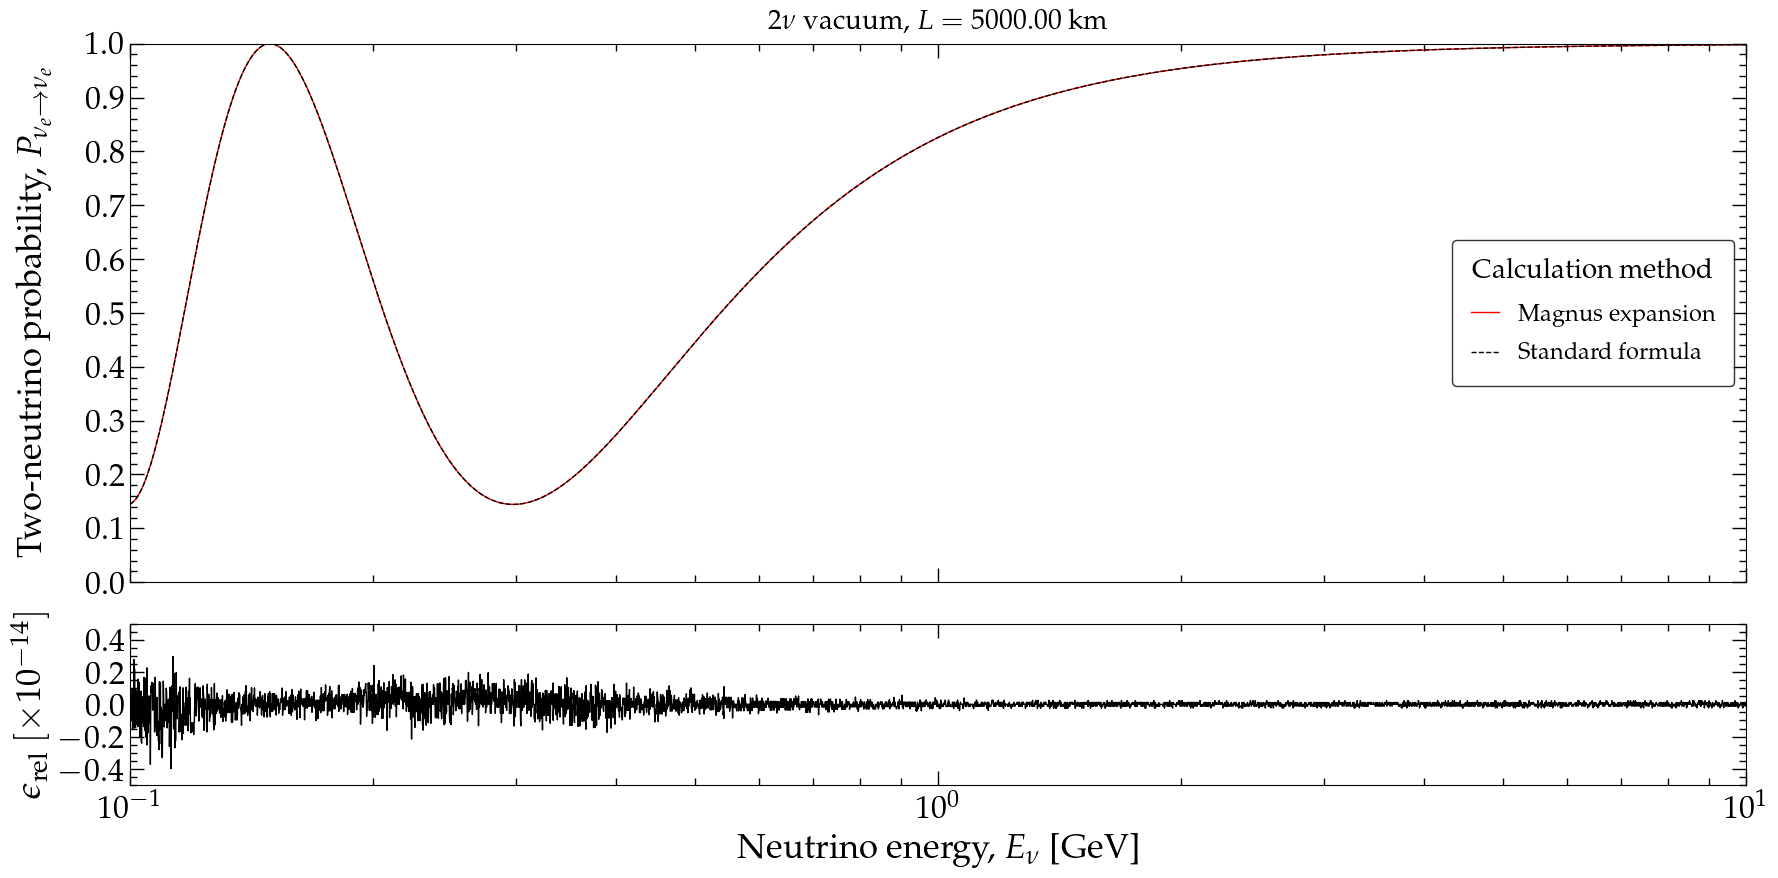

In [14]:
heights = [1.0, 0.3]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

ax[0].plot(energies, prob, lw=1, color='r', ls='-', label='Magnus expansion')
ax[0].plot(energies, prob_std, lw=1, color='k', ls='--', label='Standard formula')
ax[1].plot(energies, (prob-prob_std)/prob_std/1.e-14, lw=1, color='k', ls='-')

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='center right', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1,
             title=r'Calculation method')

# Formatting
ax[0].set_ylabel(r'Two-neutrino probability,~'+prob_label(nu_i, nu_f), labelpad=25)
ax[0].set_xlim(energy_min, energy_max)
ax[0].set_ylim(0, 1)
ax[0].set_xscale('log')
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax[0].xaxis.set_ticklabels([])
ax[1].set_xlabel(r'Neutrino energy, $E_\nu$ [GeV]')
ax[1].set_ylabel(r'$\epsilon_{\rm rel}~[\times 10^{-14}]$', labelpad=7)
ax[1].set_xscale('log')
ax[1].set_xlim(energy_min, energy_max)
ax[1].set_ylim(-0.5,0.5)
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.20))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.05))
ax[0].set_title(r'$2\nu$~vacuum, $L = $~{:.2f}~km'.format(baseline), fontsize=20, pad=10)

# Save plot
plt.tight_layout()
plt.savefig('../fig/prob_2nu_vacuum_vs_energy.pdf', dpi=200)

# 2. Probabilities 2$\nu$: in matter with constant density

In [4]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF # [adim]
Dm2 = gd.D21_NO_BF # [eV^2]

## 2.1 Probabilities vs. distance

### Generate probabilities

In [41]:
# Baselines
l_ini, l_fin = 1.e1, 1.e5 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 10.0*gd.UNIT_MEV # [eV]

# In matter
rho = 10.0 # Matter density [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]
# Using standard formula
prob_matt_std = np.array([oscprobstd.osc_prob_2nu_matter_std(sth, Dm2, VCC, energy, l*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f] for l in distances])
# Using Magnus expansion
H_func = lambda l: hamiltonians2nu.hamiltonian_2nu_vacuum(energy, sth, Dm2) - hamiltonians2nu.hamiltonian_2nu_matter(VCC)
prob_matt = np.array([oscprob.osc_prob(H_func, 0, l*gd.CONV_KM_TO_INV_EV, magnus_exp_order=1,
                                      epsabs=1.e-10, epsrel=1.e-10, limit=300)[nu_i][nu_f] for l in distances])

# In vacuum
# # Using standard formula
# prob_std = np.array([oscprobstd.osc_prob_2nu_vacuum_std(sth, Dm2, energy, l*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f] for l in distances])
# Using Magnus expansion
H_func = lambda l: hamiltonians2nu.hamiltonian_2nu_vacuum(energy, sth, Dm2)
prob_vac = np.array([oscprob.osc_prob(H_func, 0.0, l*gd.CONV_KM_TO_INV_EV, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

### Plot probabilities

Text(0.5, 1.0, '$2\\nu$~constant-density matter, $E_\\nu = $~10.00~MeV')

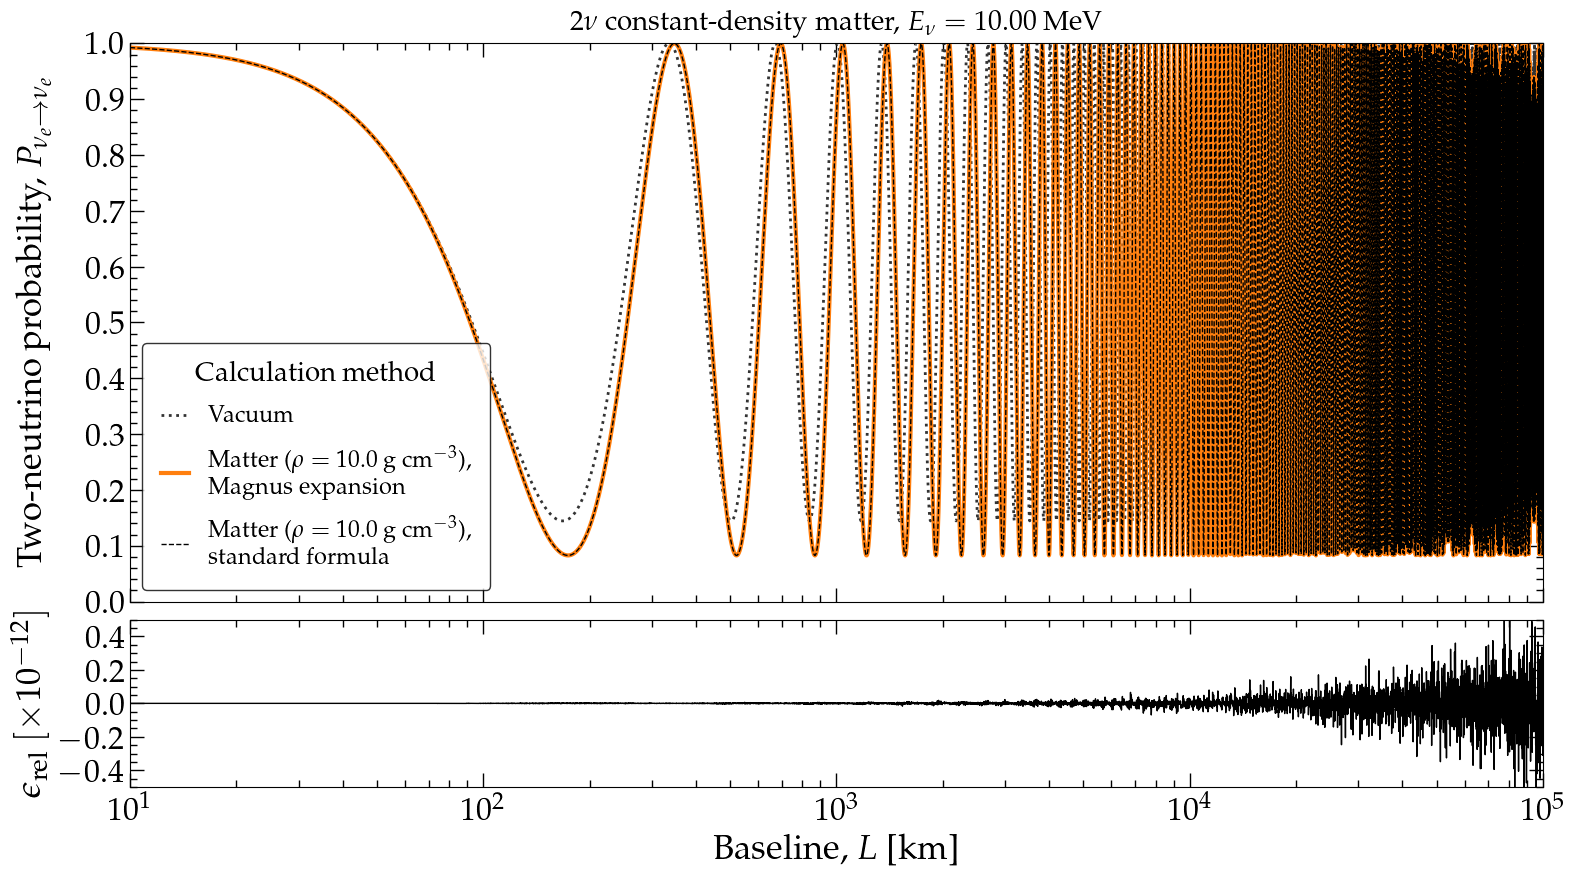

In [42]:
heights = [1.0, 0.3]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    # constrained_layout=True, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

ax[0].plot(distances, prob_vac, lw=2, color='0.2', ls=':', label=r'Vacuum')
ax[0].plot(distances, prob_matt, lw=3, color='C1', ls='-', label=r'Matter ($\rho = $~{:.1f}'.format(rho)+r'~g~cm$^{-3}$),'
           +'\n'+'Magnus expansion')
ax[0].plot(distances, prob_matt_std, lw=1, color='k', ls='--', label=r'Matter ($\rho = $~{:.1f}'.format(rho)+r'~g~cm$^{-3}$),'
           +'\n'+'standard formula')
ax[1].plot(distances, (prob_matt-prob_matt_std)/prob_matt_std/1.e-12, lw=1, color='k', ls='-')

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='lower left', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1,
             title=r'Calculation method')

# Formatting
ax[0].set_ylabel(r'Two-neutrino probability,~'+prob_label(nu_i, nu_f), labelpad=25)
ax[0].set_xlim(l_ini, l_fin)
ax[0].set_ylim(0, 1)
ax[0].set_xscale('log')
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax[0].xaxis.set_ticklabels([])
ax[1].set_xlabel(r'Baseline, $L$ [km]')
ax[1].set_ylabel(r'$\epsilon_{\rm rel}~[\times 10^{-12}]$', labelpad=7)
ax[1].set_xscale('log')
ax[1].set_xlim(l_ini, l_fin)
ax[1].set_ylim(-0.5,0.5)
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.20))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.05))
ax[0].set_title(r'$2\nu$~constant-density matter, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV), fontsize=20, pad=10)

# Save plot
# plt.tight_layout()
# plt.savefig('../fig/prob_2nu_matter_const_density_vs_baseline.pdf', dpi=200)

## 2.2 Probabilities vs. energy

### Generate probabilities

In [47]:
# Baselines
energy_min, energy_max = 1.e-1, 1.e1 # [GeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [GeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = 5.e3 # [km]

# In matter
rho = 10.0 # Matter density [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]
# Using standard formula
prob_matt_std = np.array([oscprobstd.osc_prob_2nu_matter_std(sth, Dm2, VCC, enu*gd.UNIT_GEV, baseline*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f] \
                     for enu in energies])

# Using Magnus expansion
H_vac_energy_indep = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E)
H_matt = hamiltonians2nu.hamiltonian_2nu_matter(VCC)
prob_matt = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_GEV))*H_vac_energy_indep-H_matt, 
                                       0.0, gd.CONV_KM_TO_INV_EV*baseline, magnus_exp_order=2)[nu_i][nu_f] for enu in energies])

# In vacuum
# # Using standard formula
# prob_vac = np.array([oscprobstd.osc_prob_2nu_vacuum_std(sth, Dm2, enu*gd.UNIT_GEV, baseline*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f] \
#                      for enu in energies])
# Using Magnus expansion
H = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E)
prob_vac = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_GEV))*H, 0.0, gd.CONV_KM_TO_INV_EV*baseline, magnus_exp_order=2)[nu_i][nu_f] \
                 for enu in energies])

### Plot probabilities

Text(0.5, 1.0, '$2\\nu$~constant-density matter, $L = $~5000.00~km')

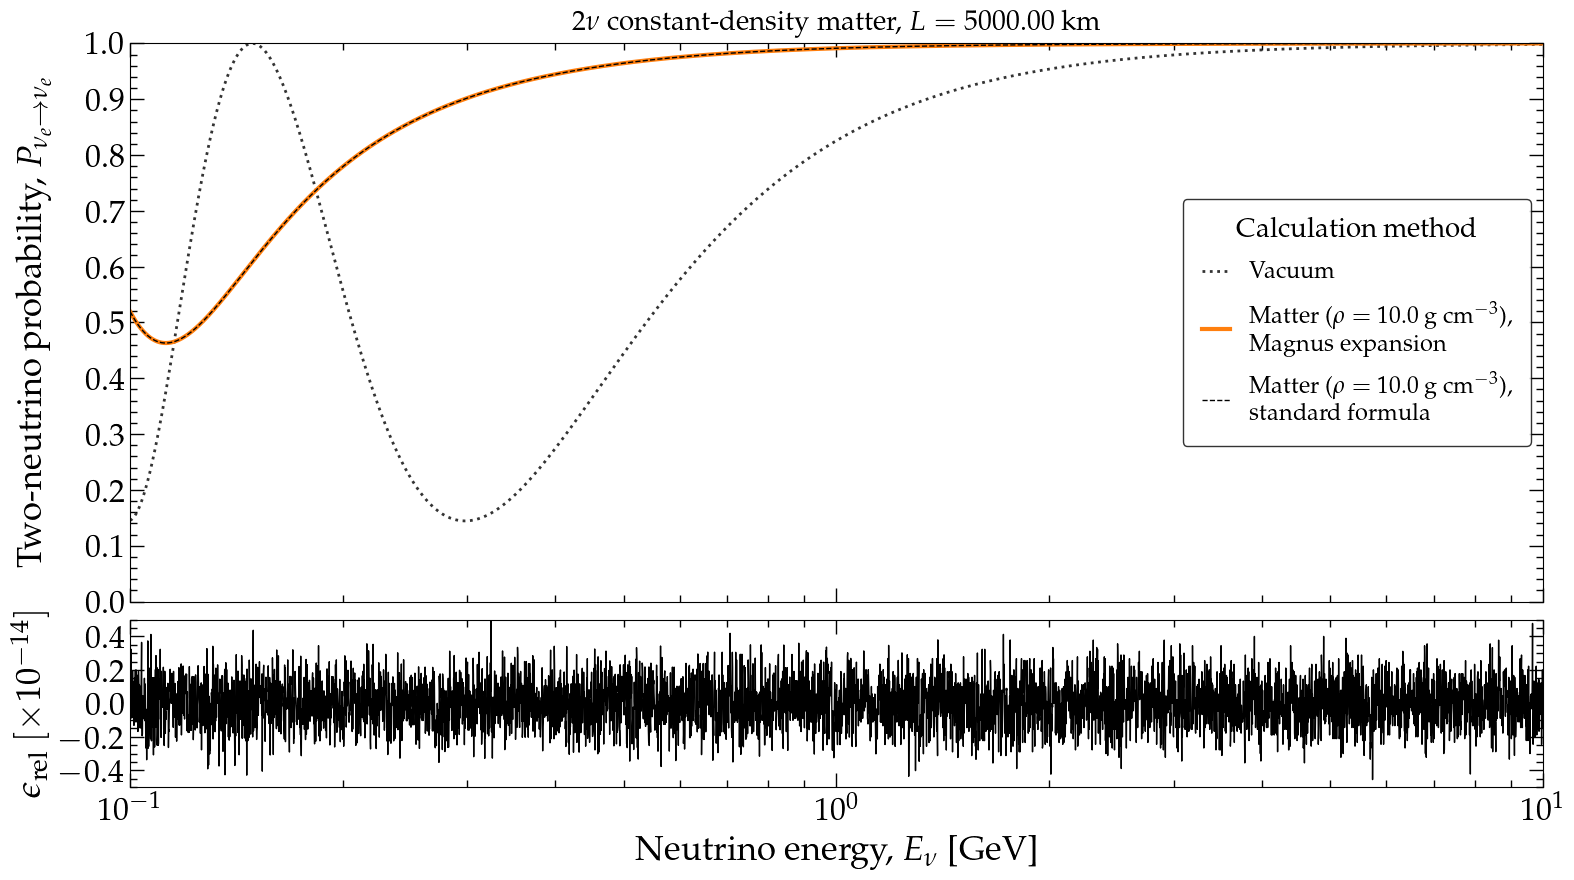

In [49]:
heights = [1.0, 0.3]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

ax[0].plot(energies, prob_vac, lw=2, color='0.2', ls=':', label=r'Vacuum')
ax[0].plot(energies, prob_matt, lw=3, color='C1', ls='-', label=r'Matter ($\rho = $~{:.1f}'.format(rho)+r'~g~cm$^{-3}$),'
           +'\n'+'Magnus expansion')
ax[0].plot(energies, prob_matt_std, lw=1, color='k', ls='--', label=r'Matter ($\rho = $~{:.1f}'.format(rho)+r'~g~cm$^{-3}$),'
           +'\n'+'standard formula')
ax[1].plot(energies, (prob_matt-prob_matt_std)/prob_matt_std/1.e-14, lw=1, color='k', ls='-')

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='center right', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1,
             title=r'Calculation method')

# Formatting
ax[0].set_ylabel(r'Two-neutrino probability,~'+prob_label(nu_i, nu_f), labelpad=25)
ax[0].set_xlim(energy_min, energy_max)
ax[0].set_ylim(0, 1)
ax[0].set_xscale('log')
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax[0].xaxis.set_ticklabels([])
ax[1].set_xlabel(r'Neutrino energy, $E_\nu$ [GeV]')
ax[1].set_ylabel(r'$\epsilon_{\rm rel}~[\times 10^{-14}]$', labelpad=7)
ax[1].set_xscale('log')
ax[1].set_xlim(energy_min, energy_max)
ax[1].set_ylim(-0.5,0.5)
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.20))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.05))
ax[0].set_title(r'$2\nu$~constant-density matter, $L = $~{:.2f}~km'.format(baseline), fontsize=20, pad=10)

# Save plot
# plt.tight_layout()
# plt.savefig('../fig/prob_2nu_matter_const_density_vs_energy.pdf', dpi=200)

# 4. Probabilities 2$\nu$: in the Sun

In [4]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF # [adim]
Dm2 = gd.D21_NO_BF # [eV^2]

In [32]:
# Parameters for the electron number density in the Sun, Eq. (10.62) in Giunti & Kim
num_density_e_center_sun = 245*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
l_scale_sun = gd.SUN_RADIUS/10.54 # [km]

# Potential assuming constant density: the matter density is constant, so this is merely a wrapper.
# [l] = km
def num_density_e_sun_const_func(l):
    return num_density_e_center_sun # [eV^3]
def VCC_func_const_density_sun(l):
    return matter.VCC_func(l, num_density_e_sun_const_func) # [eV]

# Potential assuming exponentially decreasing density
# [l] = km
def num_density_e_sun_exp_func(l):
    return num_density_e_center_sun*np.exp(-(l/gd.CONV_KM_TO_INV_EV)/l_scale_sun) # [eV^3]
def VCC_func_exp_sun(l):
    return matter.VCC_func(l, num_density_e_sun_exp_func) # [eV]

## 4.1 Probabilities vs. distance

### Generate probabilities

In [35]:
# Baselines
l_ini, l_fin = 1.e-3, 1.0 # l/SUN_RADIUS
l_npts = 1000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # l/SUN_RADIUS

# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 5.0*gd.UNIT_MEV # [eV]

# --------------------------------------------------------------
# In matter, constant density equal to central solar density
# --------------------------------------------------------------
H_func_const_density = lambda l: hamiltonians2nu.hamiltonian_2nu_vacuum(energy, sth, Dm2) \
                                      - hamiltonians2nu.hamiltonian_2nu_matter(VCC_func_const_density_sun(l))
prob_matt_const_density = np.array([oscprob.osc_prob(H_func_const_density, 
                                                     0, l*gd.SUN_RADIUS*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In matter, solar matter density profile
# --------------------------------------------------------------
H_func_exp_density = lambda l: hamiltonians2nu.hamiltonian_2nu_vacuum(energy, sth, Dm2) \
                                      - hamiltonians2nu.hamiltonian_2nu_matter(VCC_func_exp_sun(l))
# H_func_exp_density = lambda l: hamiltonians2nu.hamiltonian_2nu_vacuum(energy, sth, Dm2) \
                                      # + hamiltonians2nu.hamiltonian_2nu_matter(-VCC_func_exp_sun(l))
prob_matt_exp_density = np.array([oscprob.osc_prob(H_func_exp_density, 
                                                   0, l*gd.SUN_RADIUS*gd.CONV_KM_TO_INV_EV, 
                                                   n_slabs=200, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=8)[nu_i][nu_f] \
                                  for l in distances])

# --------------------------------------------------------------
# In vacuum
# --------------------------------------------------------------
# Using Magnus expansion
H_func = lambda l: hamiltonians2nu.hamiltonian_2nu_vacuum(energy, sth, Dm2)
prob_vac = np.array([oscprob.osc_prob(H_func,
                                      0.0, l*gd.SUN_RADIUS*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])
# # Using standard formula
# prob_std = np.array([oscprobstd.osc_prob_2nu_vacuum_std(sth, Dm2, energy, l*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f] for l in distances])

### Plot probabilities

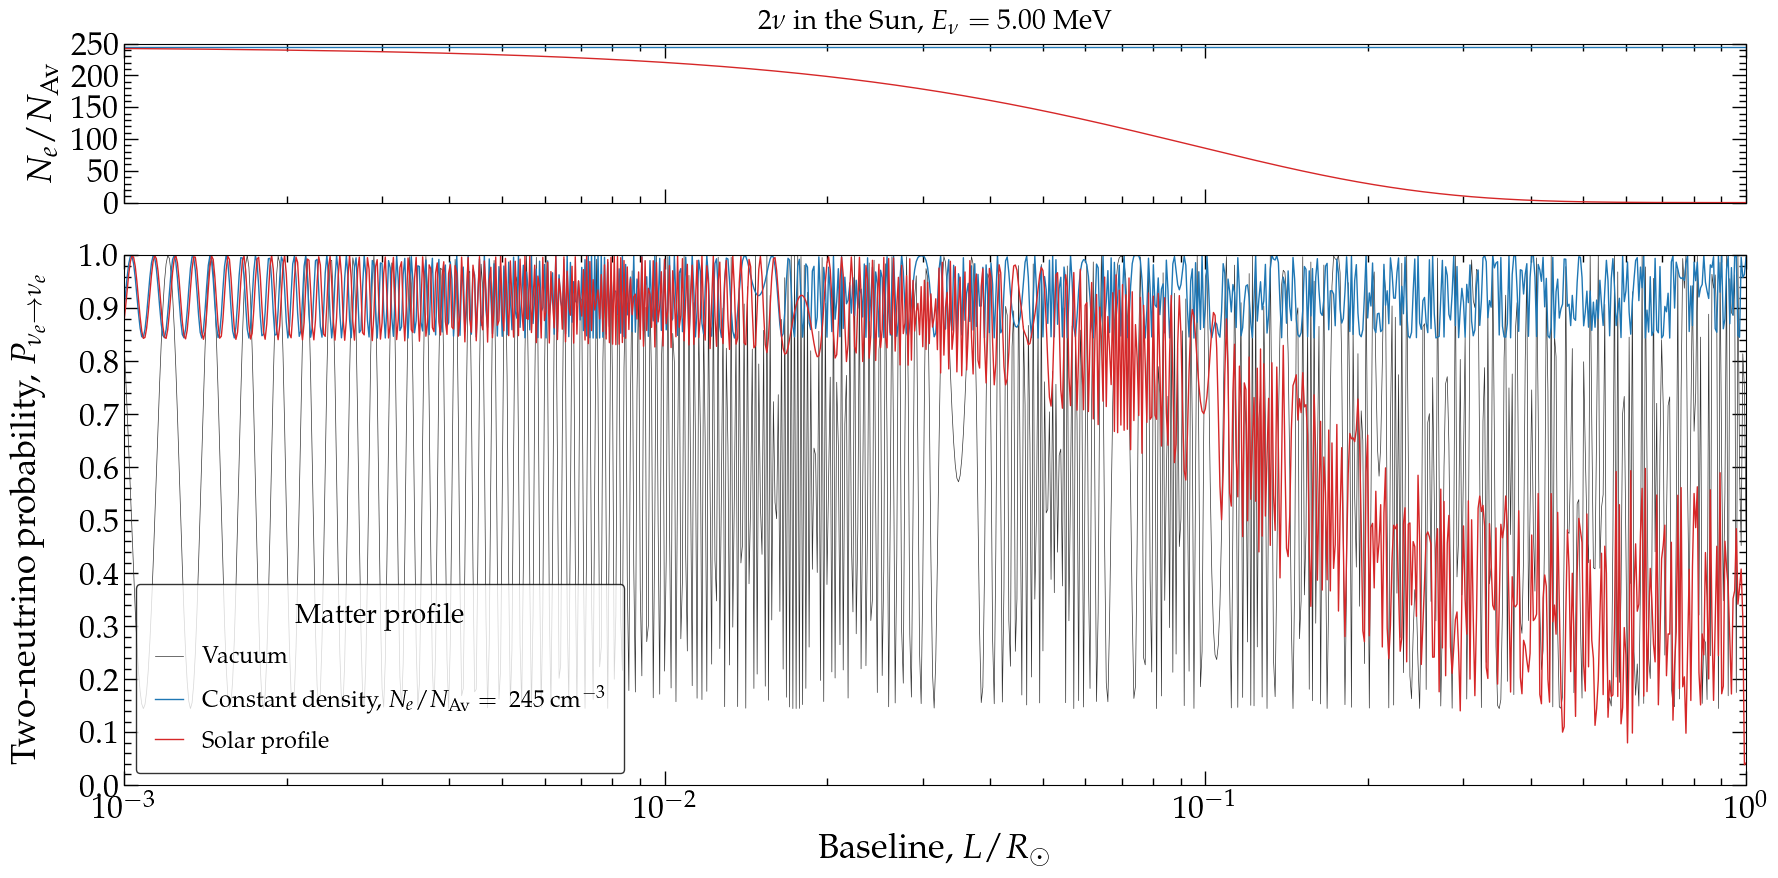

In [36]:
heights = [0.3, 1.0]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    # constrained_layout=True, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

# Density profiles
ax[0].plot(distances, [num_density_e_center_sun/(gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0)) for l in distances], lw=1, ls='-', c='C0')
ax[0].plot(distances, [num_density_e_center_sun/(gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0))*np.exp(-l*gd.SUN_RADIUS/l_scale_sun)
                        for l in distances], lw=1, ls='-', c='C3')

# Probabilities
ax[1].plot(distances, prob_vac, lw=0.5, c='0.2', ls='-', label=r'Vacuum')
ax[1].plot(distances, prob_matt_const_density, lw=1, c='C0', ls='-', 
           label=r'Constant density, $N_e/N_{\rm Av} =~$'+'{:.0f}'.format(num_density_e_center_sun/(gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0))) \
           + r'~cm$^{-3}$')
ax[1].plot(distances, prob_matt_exp_density, lw=1, c='C3', ls='-', label=r'Solar profile')

# Legend
ax[1].legend(fontsize=17, frameon=True, loc='lower left', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Matter profile')

# Formatting
ax[0].set_ylabel(r'$N_e/N_{\rm Av}$', labelpad=7)
ax[0].set_xscale('log')
ax[0].set_xlim(l_ini, l_fin)
ax[0].set_ylim(0, 250)
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=50))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=10))
ax[0].xaxis.set_ticklabels([])
ax[0].set_title(r'$2\nu$~in the Sun, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV), fontsize=20, pad=10)
ax[1].set_xlabel(r'Baseline, $L/R_\odot$')
ax[1].set_ylabel(r'Two-neutrino probability,~'+prob_label(nu_i, nu_f), labelpad=25)
ax[1].set_xlim(l_ini, l_fin)
ax[1].set_ylim(0, 1)
ax[1].set_xscale('log')
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))

# Save plot
plt.tight_layout()
plt.savefig('../fig/prob_2nu_sun_vs_baseline.pdf', dpi=200)

## 4.2 Probabilities vs. energy

### Generate probabilities

In [72]:
# Energies
energy_min, energy_max = 1.e-1, 1.e2 # [MeV]
energy_npts = 1000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = gd.SUN_RADIUS # [km]

H_vac_energy_indep = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E) [eV^2]

# --------------------------------------------------------------
# In matter, constant density equal to central solar density
# --------------------------------------------------------------
H_matt = hamiltonians2nu.hamiltonian_2nu_matter(VCC_func_const_density_sun(0.0)) # Matter Hamiltonian [eV]
def H_func_const_density(l, energy):
    return (1/energy)*H_vac_energy_indep-H_matt
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, enu*gd.UNIT_MEV), 
                                                     0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])

# --------------------------------------------------------------
# In matter, solar matter density profile
# --------------------------------------------------------------
def H_func_exp_density(l, energy):
    return (1/energy)*H_vac_energy_indep-hamiltonians2nu.hamiltonian_2nu_matter(VCC_func_exp_sun(l)) 
prob_matt_exp_density = np.array([oscprob.osc_prob(lambda l: H_func_exp_density(l, enu*gd.UNIT_MEV), 
                                                   0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                   n_slabs=200, n_tpts_per_slab=100, magnus_exp_order=2, n_jobs=10)[nu_i][nu_f] \
                                                   # n_slabs=200, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=8)[nu_i][nu_f] \
                                  for enu in energies])

# --------------------------------------------------------------
# In vacuum
# --------------------------------------------------------------
prob_vac = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_MEV))*H_vac_energy_indep, 
                                      0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])

### Plot probabilities

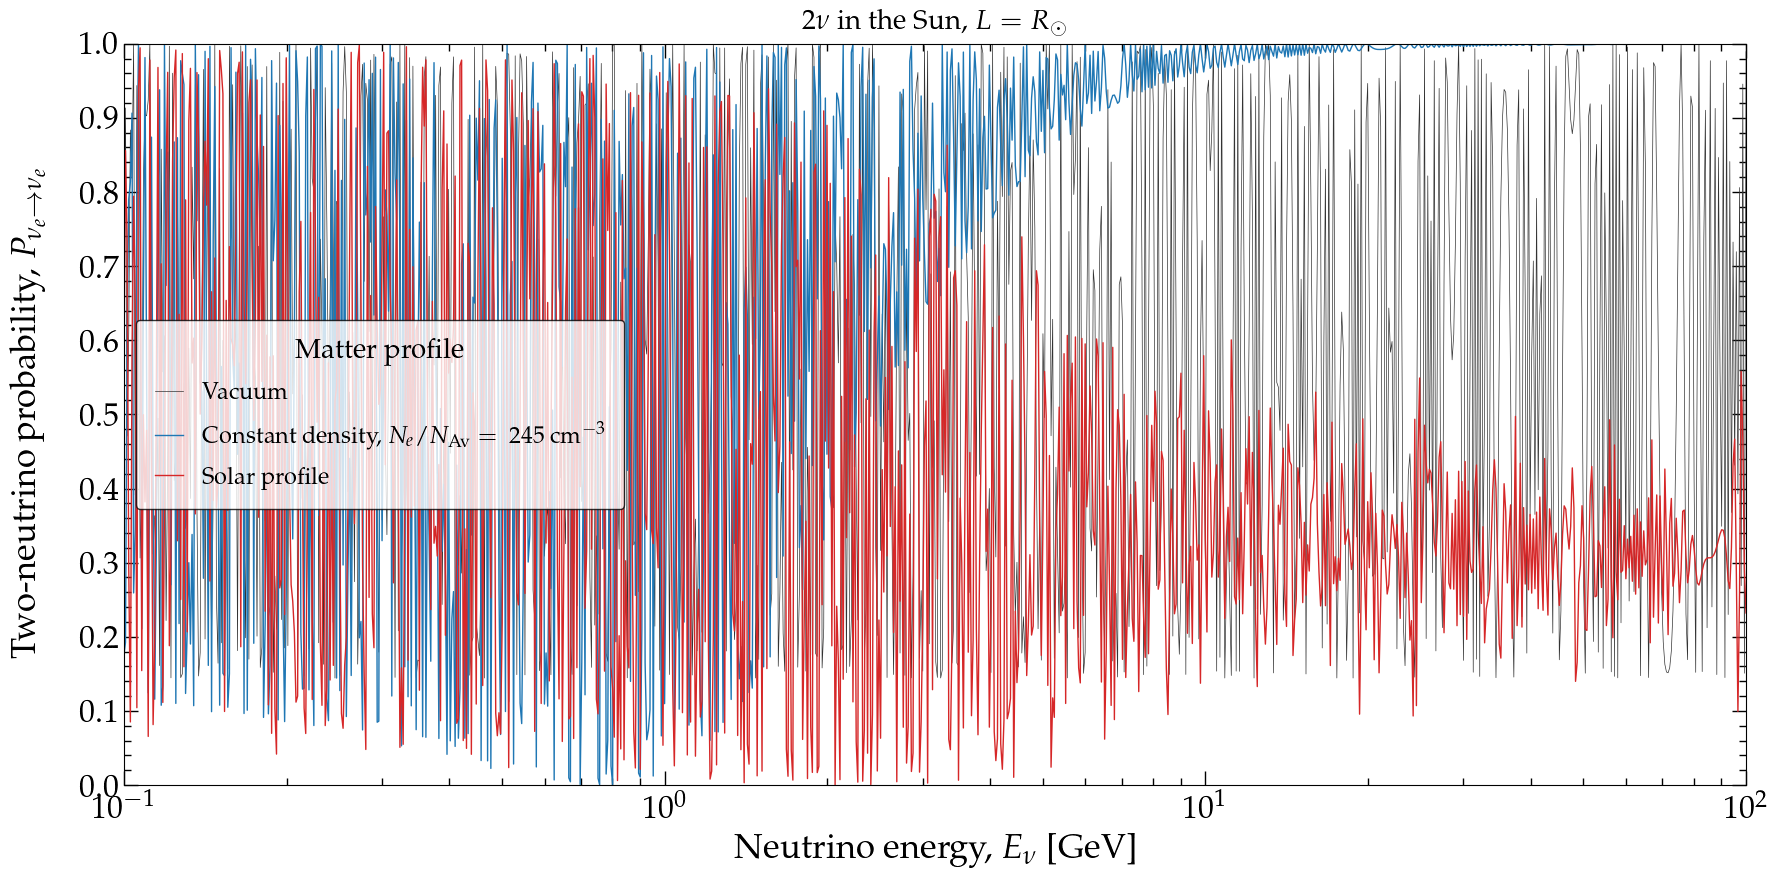

In [73]:
heights = [1.0]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=1, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)


# Probabilities
ax.plot(energies, prob_vac, lw=0.5, c='0.2', ls='-', label=r'Vacuum')
ax.plot(energies, prob_matt_const_density, lw=1, c='C0', ls='-', 
           label=r'Constant density, $N_e/N_{\rm Av} =~$'+'{:.0f}'.format(num_density_e_center_sun/(gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0))) \
           + r'~cm$^{-3}$')
ax.plot(energies, prob_matt_exp_density, lw=1, c='C3', ls='-', label=r'Solar profile')

# Legend
ax.legend(fontsize=17, frameon=True, loc='center left', handlelength=1.2, handleheight=0.7, 
          borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Matter profile') 

# Formatting
ax.set_title(r'$2\nu$~in the Sun, $L = R_\odot$', fontsize=20, pad=10)
ax.set_xlabel(r'Neutrino energy, $E_\nu$ [GeV]')
ax.set_ylabel(r'Two-neutrino probability,~'+prob_label(nu_i, nu_f), labelpad=25)
ax.set_xlim(energy_min, energy_max)
ax.set_ylim(0, 1)
ax.set_xscale('log')
ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))

# Save plot
plt.tight_layout()
plt.savefig('../fig/prob_2nu_sun_vs_energy.pdf', dpi=200)